In [95]:
import numpy as np 
import pandas as pd 
import os 
def load_kaggle_comp_data(filename, dataset_slug):
    """
    Automatically detects the environment and loads a CSV file 
    using either the local path or the Kaggle server path.
    
    Parameters:
    - filename (str): The name of the file (e.g., 'patients.csv')
    - dataset_slug (str): The dataset folder name used on Kaggle (e.g., 'username/dataset_name')
    """

    kaggle_path = os.path.join('/kaggle/input/competitions/playground-series-s6e7', dataset_slug, filename)
  
    if os.path.exists(kaggle_path):
        print(f"✈️ Running on Kaggle. Loading: {kaggle_path}")
        return pd.read_csv(kaggle_path)
    else:
        print(f"🏠 Running locally. Loading: {filename}")
        return pd.read_csv('../data/competitions/student-health-risk/'+filename)

test_data = load_kaggle_comp_data("test.csv","competitions/playground-series-s6e7")
train_data = load_kaggle_comp_data("train.csv","competitions/playground-series-s6e7")

🏠 Running locally. Loading: test.csv
🏠 Running locally. Loading: train.csv


In [96]:
train_data.shape

(690088, 15)

In [97]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [98]:
train_data.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [99]:
train_data.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [100]:
train_data.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [101]:
train_data.smoking_alcohol.unique()

<StringArray>
['yes', 'occasional', nan, 'no']
Length: 4, dtype: str

In [102]:
train_data.diet_type.unique()

<StringArray>
['veg', 'non-veg', 'balanced', nan]
Length: 4, dtype: str

In [103]:
train_data.stress_level.unique()

<StringArray>
['high', 'low', nan, 'medium']
Length: 4, dtype: str

In [104]:
train_data.sleep_quality.unique()

<StringArray>
['average', 'poor', nan, 'good']
Length: 4, dtype: str

In [105]:
train_data.physical_activity_level.unique()

<StringArray>
['sedentary', 'moderate', 'active', nan]
Length: 4, dtype: str

In [106]:
train_data.health_condition.unique()

<StringArray>
['unhealthy', 'at-risk', 'fit']
Length: 3, dtype: str

In [107]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

categorical_cols = train_data.select_dtypes(include=['object', 'category']).columns.tolist()


if 'health_condition' in categorical_cols:
    categorical_cols.remove('health_condition')

for col in categorical_cols:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])

# 2. Adım: Target sütununu sayıya çevir
health_map = {'unhealthy': 0, 'at-risk': 1, 'fit': 2}
train_data['health_condition'] = train_data['health_condition'].map(health_map)


train_data = pd.get_dummies(train_data, columns=categorical_cols, dtype=int)


/var/folders/b_/5_5smxjd37nf2c_h02fxq_pm0000gn/T/ipykernel_19956/3579783129.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_data.select_dtypes(include=['object', 'category']).columns.tolist()


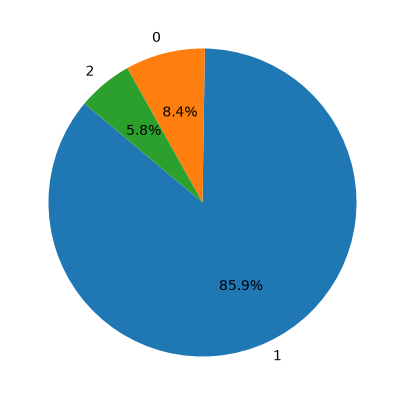

In [108]:
import matplotlib.pyplot as plt 
su_counts = train_data.health_condition.value_counts()
fig, ax = plt.subplots(figsize=(5,5))

# 3. Feed the data and the labels to the pie chart
plt.pie(
    su_counts, 
    labels=su_counts.index,
    autopct="%1.1f%%", 
    startangle=140      # Tilts the pie chart for a nicer starting view
)

In [109]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report
from lightgbm import LGBMClassifier

y = train_data['health_condition']
features_to_drop = ['health_condition']
if 'id' in train_data.columns:
    features_to_drop.append('id')

X = train_data.drop(columns=features_to_drop)
# 1. Train-Test Bölmesini Yapıyoruz
# stratify=y burada HAYATİ öneme sahip, az olan sınıfları train ve teste eşit dağıtır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. LightGBM Modelini Dengeli Ağırlıkla Tanımlıyoruz
lgb_model = LGBMClassifier(
    class_weight='balanced',
    n_estimators=300,       # Ağaç sayısını artırdık (Daha derin öğrenme)
    learning_rate=0.05,     # Öğrenme hızını düşürdük (Daha temkinli ve hatasız ilerleme)
    max_depth=7,            # Aşırı öğrenmeyi (overfitting) engellemek için derinlik sınırı
    num_leaves=64,          # Yaprak sayısı
    random_state=42,
    n_jobs=-1
)

# 3. Modeli Eğitiyoruz
lgb_model.fit(X_train, y_train)

# 4. Balanced Accuracy Skorumuzu Ölçüyoruz
y_pred = lgb_model.predict(X_test)
score = balanced_accuracy_score(y_test, y_pred)

print(f"Işık Hızında LightGBM Dengeli Başarı Skoru: %{score * 100:.2f}")
print("\nSınıf Bazlı Detaylı Rapor:")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001779 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1820
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 25
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

In [110]:
import pandas as pd

# ---------------------------------------------------------
# Adım 1: ID'yi Saklama ve Kategorik Sütunları Tespit Etme
# ---------------------------------------------------------
# Test ID'lerini ilerisi için güvene alıyoruz
test_ids = test_data['id']

# Kategorik sütunları otomatik buluyoruz
test_categorical_cols = test_data.select_dtypes(include=['object', 'category']).columns.tolist()

# Eğer 'id' veya 'health_condition' bu listedeyse çıkartıyoruz
for col in ['id', 'health_condition']:
    if col in test_categorical_cols:
        test_categorical_cols.remove(col)

# ---------------------------------------------------------
# Adım 2: Gözden Kaçan Sütunu Ayıklama (Örn: yes/no sütunu)
# ---------------------------------------------------------
# Hatırlarsan train setinde bu sütunu One-Hot yapmak yerine 0,1,2 diye map etmiştik.
# Liste içinden bu spesifik sütunu bulup manuel map işlemine alıyoruz:
kacan_sutun_adi = None
for col in test_categorical_cols:
    # İçinde 'yes' veya 'no' barındıran sütunu tespit et
    if test_data[col].astype(str).str.contains('yes|no|occasional', case=False, na=False).any():
        kacan_sutun_adi = col
        break

if kacan_sutun_adi:
    # Önce eksik verisini doldur
    test_data[kacan_sutun_adi] = test_data[kacan_sutun_adi].fillna(test_data[kacan_sutun_adi].mode()[0])
    # Train setindeki sırayla birebir aynı şekilde map et
    kacan_map = {'no': 0, 'occasional': 1, 'yes': 2}
    test_data[kacan_sutun_adi] = test_data[kacan_sutun_adi].map(kacan_map)
    # Bu sütunu artık One-Hot listesinden çıkarıyoruz ki get_dummies'e girmesin
    test_categorical_cols.remove(kacan_sutun_adi)

# ---------------------------------------------------------
# Adım 3: Geriye Kalan Sırasız Kategorik Sütunları Doldurma ve One-Hot
# ---------------------------------------------------------
# Eksik verileri doldur (Train setindeki mantıkla)
for col in test_categorical_cols:
    test_data[col] = test_data[col].fillna(test_data[col].mode()[0])

# Kalan tüm sırasız sütunları One-Hot Encoding yap
test_data = pd.get_dummies(test_data, columns=test_categorical_cols, dtype=int)

# ---------------------------------------------------------
# Adım 4: Sütunları Hizalama ve Tahmin (En Kritik Nokta)
# ---------------------------------------------------------
# ID sütununu girdilerden düşüyoruz
X_test_final = test_data.drop(columns=['id'], errors='ignore')

# Test sütunlarını, eğitilen X (train) sütunlarıyla birebir eşle (eksikleri 0 yap)
X_test_final = X_test_final.reindex(columns=X.columns, fill_value=0)

# En son eğittiğimiz PARAMETRESİ AYARLANMIŞ modele (tuned_lgb) tahmin yaptırıyoruz
test_predictions = lgb_model.predict(X_test_final)

# ---------------------------------------------------------
# Adım 5: Sayıları Yazıya Çevirme ve Kaydetme
# ---------------------------------------------------------
# Sayısal sonuçları Kaggle'ın kabul ettiği metin formatına çeviriyoruz
inverse_health_map = {0: 'unhealthy', 1: 'at-risk', 2: 'fit'}
mapped_predictions = [inverse_health_map[pred] for pred in test_predictions]

# İstenen submission dataframe yapısını oluştur
submission = pd.DataFrame({
    'id': test_ids,
    'health_condition': mapped_predictions
})

# CSV olarak diske kaydet
submission.to_csv('submission.csv', index=False)

print("Submission dosyası 'submission.csv' başarıyla oluşturuldu! Kaggle'a yüklemeye hazır.")

/var/folders/b_/5_5smxjd37nf2c_h02fxq_pm0000gn/T/ipykernel_19956/1891384012.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  test_categorical_cols = test_data.select_dtypes(include=['object', 'category']).columns.tolist()


Submission dosyası 'submission.csv' başarıyla oluşturuldu! Kaggle'a yüklemeye hazır.
